In [ ]:
# 1. Подключение нужных для работы моделей
import pandas as pd     # для чтения и записи табличных файлов
import numpy as np      # для математической обработки данных
import matplotlib.pyplot as plt # для построения графиков
from scipy.signal import find_peaks

In [ ]:
# 2. Получение и чтение Excel файла из облака (ЗАДАНИЕ 2)
url = "https://drive.google.com/uc?export=download&id=1KfIzbQZwilaAL_W2vr5vcVjbVlYLQOb6"

# имен у столбцов в исходном файле нет, поэтому нужно указать header = None.
input_df = pd.read_excel(url, header = None)

# 3. вывод заголовка таблицы и первых пяти строк (сэмплов) (ЗАДАНИЕ 3)
input_df.head()

,0,1,2
0,01.01.2015 0:30:00,1463.0,1776.5
1,01.01.2015 1:00:00,1452.0,1765.5
2,01.01.2015 1:30:00,1391.5,1699.5
3,01.01.2015 2:00:00,1435.5,1749.0
4,01.01.2015 2:30:00,1435.5,1749.0


In [ ]:
# вывод последних пяти строк (сэмплов) (ЗАДАНИЕ 3)
input_df.tail()

,0,1,2
70123,31.12.2018 22:00:00,1762.0,2220.0
70124,31.12.2018 22:30:00,1679.0,2148.0
70125,31.12.2018 23:00:00,1819.0,2253.0
70126,31.12.2018 23:30:00,1566.0,2035.0
70127,01.01.2019,1587.0,2034.0


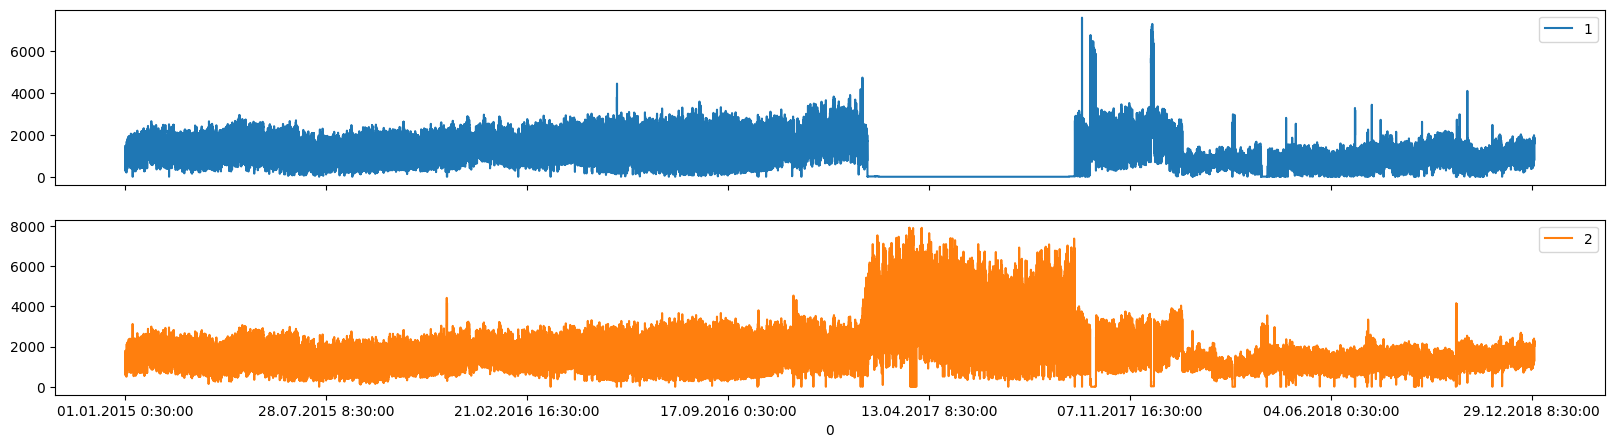

In [ ]:
# 4. Постройка графиков (ЗАДАНИЕ 4)
axes = input_df.plot(x=input_df.columns[0], marker=None, figsize=(20, 5), subplots=True)

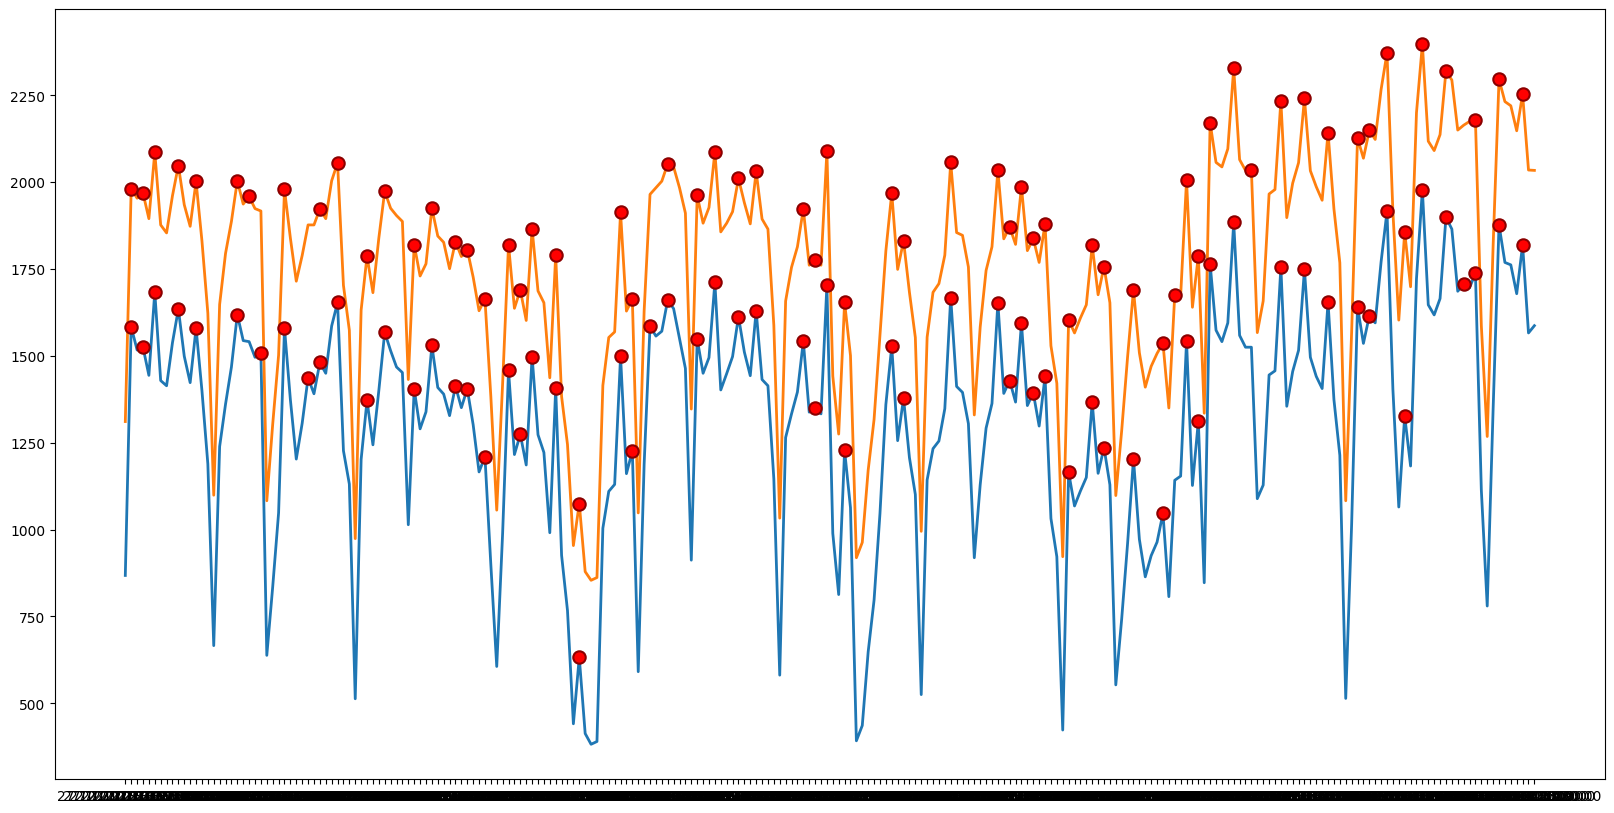

In [ ]:
#график суммарного потребления обоих разрезов за последние 5 суток и локальный максимум(ЗАДАНИЕ 5)
last_5_days = input_df.tail(240).copy()

# Создаем фигуру и оси вручную для лучшего контроля
fig, axes = plt.subplots(figsize=(20, 10))

# Строим графики по отдельности
time_column = last_5_days.columns[0]
consumption_columns = last_5_days.columns[1:]

# Словарь для хранения линий, чтобы потом на них наносить точки
lines = []
for col in consumption_columns:
    line = axes.plot(last_5_days[time_column], last_5_days[col],
                   label=col, marker=None, linewidth=2)
    lines.append(line)

# Находим и отмечаем локальные максимумы для каждого столбца
for col in consumption_columns:
    # Получаем значения
    values = last_5_days[col].values

    # Находим индексы локальных максимумов
    local_max_indices = []
    for i in range(1, len(values) - 1):
        if values[i] > values[i-1] and values[i] > values[i+1]:
            local_max_indices.append(i)

    # Если есть локальные максимумы
    if local_max_indices:
        # Получаем координаты точек
        x_points = last_5_days[time_column].iloc[local_max_indices]
        y_points = values[local_max_indices]

        # Наносим точки ТОЧНО на те же места, где проходят линии
        axes.scatter(x_points, y_points,
                  color='red', s=80, zorder=5,
                  edgecolors='darkred', linewidth=1.5)

In [ ]:
#Интеракивные графики(ЗАДАНИЕ6)

import plotly.graph_objects as go

# Получаем данные за последние 5 суток (120 часов = 240 точек при 30-минутном интервале)
last_5_days = input_df.tail(240).copy()

time_col = last_5_days.columns[0]
consumption_cols = last_5_days.columns[1:]

# Создаём фигуру
fig = go.Figure()

# Для каждого столбца потребления добавляем линию и точки локальных максимумов
for col in consumption_cols:
    # Преобразуем название столбца в строку, если оно не строка
    col_name = str(col)

    # Добавляем основную линию
    fig.add_trace(go.Scatter(
        x=last_5_days[time_col],
        y=last_5_days[col],
        mode='lines',
        name=col_name,
        line=dict(width=2),
        hovertemplate='Время: %{x}<br>Значение: %{y:.2f}<extra>' + col_name + '</extra>'
    ))

    # Поиск локальных максимумов
    values = last_5_days[col].values
    local_max_indices = [i for i in range(1, len(values)-1)
                         if values[i] > values[i-1] and values[i] > values[i+1]]

    if local_max_indices:
        # Добавляем точки локальных максимумов
        fig.add_trace(go.Scatter(
            x=last_5_days[time_col].iloc[local_max_indices],
            y=values[local_max_indices],
            mode='markers',
            name=f'{col_name} (максимумы)',
            marker=dict(
                size=10,
                color='red',
                symbol='circle',
                line=dict(color='darkred', width=1.5)
            ),
            hovertemplate='Время: %{x}<br>Локальный максимум: %{y:.2f}<extra>' + col_name + '</extra>',
            showlegend=False  # Скрываем из легенды, чтобы не дублировать
        ))

# Настройка внешнего вида
fig.update_layout(
    title=dict(
        text='<b>Суммарное потребление за последние 5 суток</b><br><sub>Красными точками отмечены локальные максимумы</sub>',
        font=dict(size=18),
        x=0.5
    ),
    xaxis_title='Время',
    yaxis_title='Потребление',
    hovermode='closest',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    width=1200,
    height=600,
    template='plotly_white'
)

# Настройка осей
fig.update_xaxes(
    tickformat='%d.%m %H:%M',
    gridcolor='lightgray',
    showgrid=True
)
fig.update_yaxes(
    gridcolor='lightgray',
    showgrid=True
)

# Добавляем кнопки управления масштабом
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1d", step="day", stepmode="backward"),
            dict(count=2, label="2d", step="day", stepmode="backward"),
            dict(count=3, label="3d", step="day", stepmode="backward"),
            dict(count=5, label="5d", step="day", stepmode="backward"),
            dict(step="all", label="Всё")
        ])
    )
)

# Показываем график
fig.show()